## Experimental conditions  


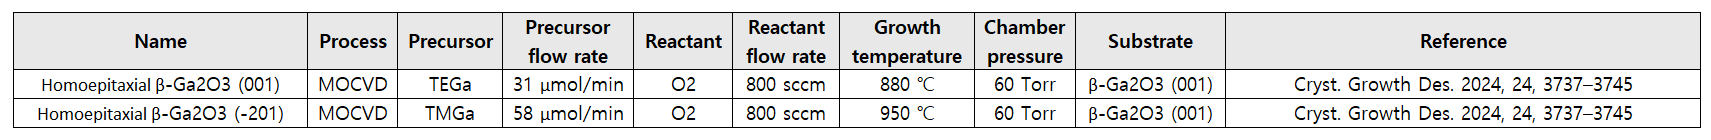

# 1. Calculating relative nucleation rates

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.patches import Wedge

In [2]:
# Physical constants
PI = math.pi
KB = 8.617e-2  # Boltzmann constant, unit: eV/K

def nucleation_rate(surface_meta, n_meta, surface_stable, n_stable, delta_g_rxn, bulk_diff, temp):
    """
    Calculate the nucleation rate
    
    Parameters:
    -----------
    surface_meta : float
        Surface energy of metastable phase (eV/Å²)
    n_meta : float
        Number of atoms per unit volume in metastable phase (atoms/Å³)
    surface_stable : float
        Surface energy of stable phase (eV/Å²)
    n_stable : float
        Number of atoms per unit volume in stable phase (atoms/Å³)
    delta_g_rxn : float
        Reaction free energy change (eV/atom)
    bulk_diff : float
        Bulk energy difference (eV/atom)
    temp : float
        Temperature (K)
    
    Returns:
    --------
    rate : float
        Calculated nucleation rate
    """
    try:
        # First term
        term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)
        
        # Second term
        term2 = surface_stable**3 / (n_stable**2 * delta_g_rxn**2)
        
        # Constant coefficient in exponent
        constant = (16 * PI) / (3 * KB * temp)
        
        # Exponent
        exponent = constant * (term1 - term2)
        
        # Nucleation rate
        rate = np.exp(exponent)
        
        return rate
        
    except ZeroDivisionError:
        raise ValueError("Division by zero: n_meta, n_stable, delta_g_rxn, or temp cannot be zero.")
    except Exception as e:
        raise ValueError(f"Unexpected error occurred: {e}")

In [3]:
# Surface energy
surface_b201 = 48.31 - 8 # Reconstruction energy (J. Mater. Chem. C, 2024, 12, 1820–1832)
surface_b001 = 101.28 

#Strain energy difference
Ediff_201_001 = 169 #meV/atom

#Density
density_b = 0.09092272200462186

#Temperature

temp = 900 + 273 # Since the growth temperatures differ, we selected a temperature between the growth temperatures of the two precursors.

C:\Users\NB\AppData\Local\Temp\ipykernel_15396\3951799056.py:33: RuntimeWarning: divide by zero encountered in divide
  term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)
C:\Users\NB\AppData\Local\Temp\ipykernel_15396\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)


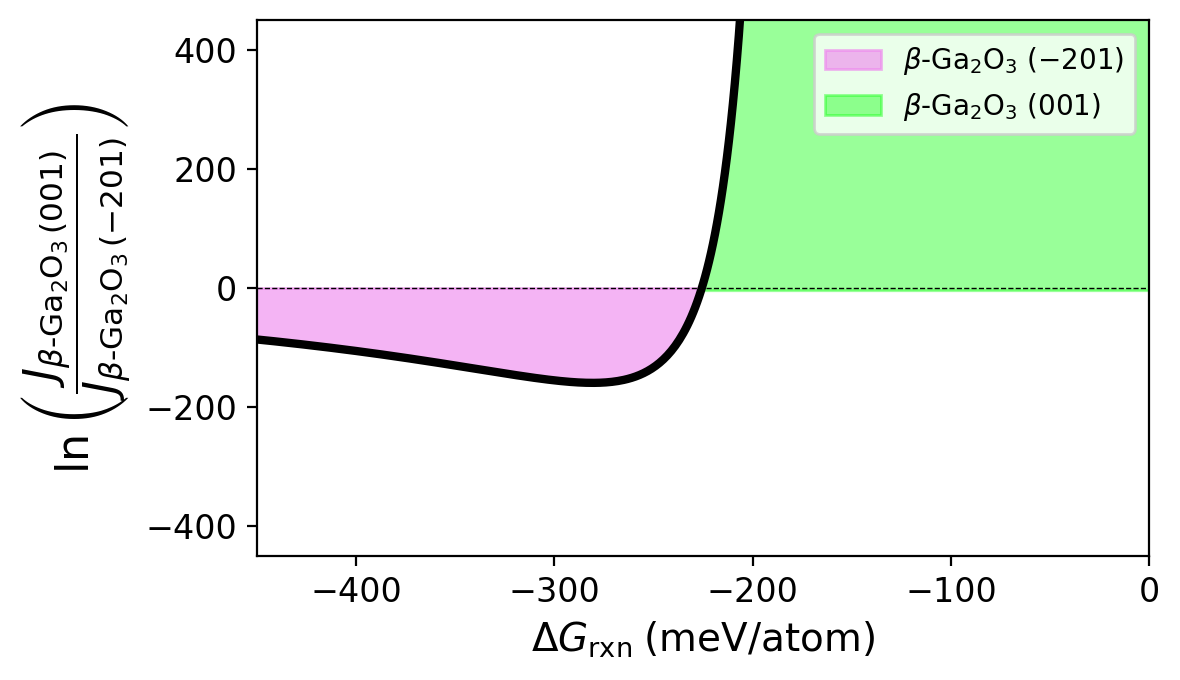

In [4]:
# Fontsize
fs = 16  # Font size

# Energy ranges (meV/atom)
delta_g_rxn = np.arange(-600, -150)
delta_g_rxn2 = np.arange(-650, -225)

# =============================================================================
# Plot: Nucleation Rate Ratio
# =============================================================================
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=200)

# Zero reference line
ax.axhline(0, color='black', linestyle='dashed', linewidth=0.5)

# Main nucleation rate curve
ln_J_ratio = np.log(nucleation_rate(
    surface_b201, density_b, 
    surface_b001, density_b, 
    delta_g_rxn, Ediff_201_001, temp
))
ax.plot(delta_g_rxn, ln_J_ratio, color='black', alpha=1, lw=3)

# Shaded region for extended range
ln_J_ratio2 = np.log(nucleation_rate(
    surface_b201, density_b, 
    surface_b001, density_b, 
    delta_g_rxn2, Ediff_201_001, temp
))
ax.fill_between(delta_g_rxn2, ln_J_ratio2, color='violet', alpha=0.6, label=r'$\beta$-Ga$_2$O$_3$ (−201)')

mask = (delta_g_rxn >= -226) & (delta_g_rxn <= -200)
delta_g_selected = delta_g_rxn[mask]
ln_J_selected = ln_J_ratio[mask]

ax.fill_betweenx(ln_J_selected, delta_g_selected, 0, color='lime', alpha=0.4, label=r'$\beta$-Ga$_2$O$_3$ (001)')
ax.legend()
# Axis settings
ax.set_xlim(-450, 0)
ax.set_ylim(-450, 450)
ax.tick_params(labelsize=fs - 4)

# Labels
ax.set_xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV/atom})$", fontsize=fs - 2)
ax.set_ylabel(
    r"$\ln \left(\dfrac{J_{\beta\text{-Ga}_{2}\text{O}_{3}\,(001)}}"
    r"{J_{\beta\text{-Ga}_{2}\text{O}_{3}\,(-201)}}\right)$",
    fontsize=fs
)

# Optional: add legend
# ax.legend(fontsize=fs - 6, loc='best')

plt.tight_layout()
plt.show()

# 2. Reaction pathfindings 

In [5]:
import numpy as np
import collections


from pymatgen.entries.computed_entries import ComputedEntry
from rxn_network.entries.entry_set import GibbsEntrySet
from rxn_network.enumerators.basic import BasicEnumerator
from rxn_network.entries.interpolated import InterpolatedEntry
import pandas as pds


c:\Users\NB\anaconda3\envs\rxn3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-08 14:08:05,581	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [6]:
# =============================================================================
# DFT-calculated Energies
# =============================================================================

# Precursors
TEGa = ComputedEntry("Ga(C2H5)3", -111.42420)
TMGa = ComputedEntry("Ga(CH3)3", -62.32542)

# Reactants
O2 = ComputedEntry("O2", -9.8799) 

# Target
Ga2O3 = ComputedEntry("Ga2O3", -29.8385)  # beta phase

# By-products
C2H4 = ComputedEntry("C2H4", -31.980520)
CH3 = ComputedEntry("CH3", -18.16748)
C2H5 = ComputedEntry("C2H5", -34.86254)
CH4 = ComputedEntry("CH4", -18.83721)
H2O = ComputedEntry("H2O", -14.233623)
CO2 = ComputedEntry("C2O4", -22.969825)
H2 = ComputedEntry("H2", -6.7903) 

# Chemical potential of Ga
Ga = ComputedEntry("Ga8", -23.23820)

In [7]:
# =============================================================================
# Physical Constants
# =============================================================================
K_B = 1.380649e-23              # Boltzmann constant (J/K)
EV_PER_J = 1 / 1.60218e-19      # J to eV conversion
MOLAR_VOLUME_STP = 22414        # cm³/mol at STP


# =============================================================================
# Functions
# =============================================================================

def ideal_gas_entry(entry, T, P, P0=1.0):
    """
    Apply ideal gas correction: E_corrected = E + kT*ln(P/P0)
    
    Parameters:
    -----------
    entry : ComputedEntry
    T : float - Temperature (K)
    P : float - Pressure (atm)
    P0 : float - Reference pressure (atm), default=1.0
    
    Returns:
    --------
    ComputedEntry with corrected energy
    """
    kT_J = K_B * T
    correction_J = kT_J * np.log(P / P0)
    correction_eV = correction_J * EV_PER_J
    
    corrected_energy = entry.energy + correction_eV
    return ComputedEntry(entry.composition, corrected_energy)


def umol_per_min_to_sccm(flow_umol_min):
    """μmol/min -> SCCM"""
    return flow_umol_min * (MOLAR_VOLUME_STP / 1e6)


# Common parameters
P_CHAMBER = 60 / 760  # 60 Torr to atm

# -----------------------------------------------------------------------------
# TEGa Condition
# -----------------------------------------------------------------------------
temp_TEGa = 880 + 273          # 880°C → K
flow_TEGa = umol_per_min_to_sccm(31)  # 31 μmol/min → SCCM
flow_O2_TEGa = 800                # SCCM
flow_total_TEGa = flow_TEGa + flow_O2_TEGa

# Partial pressures
pp_TEGa = (flow_TEGa / flow_total_TEGa) * P_CHAMBER      # TEGa partial pressure (atm)
pp_O2_TEGa = (flow_O2_TEGa / flow_total_TEGa) * P_CHAMBER  # O2 partial pressure (atm)

# Apply ideal gas correction
ideal_TEGa = ideal_gas_entry(TEGa, temp_TEGa, pp_TEGa)
ideal_O2_TEGa = ideal_gas_entry(O2, temp_TEGa, pp_O2_TEGa)

# -----------------------------------------------------------------------------
# TMGa Condition
# -----------------------------------------------------------------------------
temp_TMGa = 950 + 273          # 950°C → K
flow_TMGa = umol_per_min_to_sccm(58)  # 58 μmol/min → SCCM
flow_O2_TMGa = 800                # SCCM
flow_total_TMGa = flow_TMGa + flow_O2_TMGa

# Partial pressures
pp_TMGa = (flow_TMGa / flow_total_TMGa) * P_CHAMBER      # TMGa partial pressure (atm)
pp_O2_TMGa = (flow_O2_TMGa / flow_total_TMGa) * P_CHAMBER  # O2 partial pressure (atm)

# Apply ideal gas correction
ideal_TMGa = ideal_gas_entry(TMGa, temp_TMGa, pp_TMGa)
ideal_O2_TMGa = ideal_gas_entry(O2, temp_TMGa, pp_O2_TMGa)

In [12]:
# TMGa reaction generation
TMGa_entries = [ideal_TMGa,ideal_O2_TMGa,Ga2O3, C2H4,CH3,C2H5,CH4,H2O,CO2,H2,Ga]
TMGa_entries_inter = []


for entry in TMGa_entries:
    entry_inter = InterpolatedEntry(entry.composition, entry.energy)
    TMGa_entries_inter.append(entry_inter)

TMGa_gibbs_entries = GibbsEntrySet(entries=TMGa_entries_inter)

be_TMGa = BasicEnumerator(n=3,precursors=[ideal_TMGa.composition,ideal_O2_TMGa.composition], targets=["Ga2O3"])


TMGa_rxns = be_TMGa.enumerate(TMGa_gibbs_entries)


2026-02-08 01:52:15,460 INFO rxn_network.utils.ray Ray is not initialized. Checking for existing cluster...
2026-02-08 01:52:15,462 INFO rxn_network.utils.ray Could not identify existing Ray instance. Creating a new one...


2026-02-08 01:52:18,996	INFO worker.py:2013 -- Started a local Ray instance.


2026-02-08 01:52:21,284 INFO rxn_network.utils.ray HOST: DESKTOP-9NR7JST, Num CPUs: 8.0, Total Memory: 7129017549.0


c:\Users\NB\anaconda3\envs\rxn3\lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
Enumerating reactions (BasicEnumerator): 100%|██████████| 3/3 [00:04<00:00,  1.51s/it]


In [13]:
# TEGa reaction generation
TEGa_entries = [ideal_TEGa,ideal_O2_TEGa,Ga2O3, C2H4,CH3,C2H5,CH4,H2O,CO2,H2,Ga]
TEGa_entries_inter = []

for entry in TEGa_entries:
    entry_inter = InterpolatedEntry(entry.composition, entry.energy)
    TEGa_entries_inter.append(entry_inter)

TEGa_gibbs_entries = GibbsEntrySet(entries=TEGa_entries_inter)

be_TEGa = BasicEnumerator(n=3,precursors=[ideal_TEGa.composition,ideal_O2_TEGa.composition], targets=["Ga2O3"])


TEGa_rxns = be_TEGa.enumerate(TEGa_gibbs_entries)

Enumerating reactions (BasicEnumerator): 100%|██████████| 3/3 [00:00<00:00, 32.74it/s]


In [14]:
data = collections.defaultdict(list)

for rxn in TMGa_rxns:
    
    data["rxn"].append(rxn)
    Grxn =round(rxn.energy_per_atom*1000,2)
    data["ΔG_rxn (meV/atom)"].append(Grxn)
    data["Precursor"].append("TMGa")
    data["Reactants"].append("O2")

    
    by_products = []  
    for product in rxn.products:
        if product != Ga2O3.composition: 
            by_products.append(product.reduced_formula)
            
    # data["By-Products"].append(by_products)
    data["By-products"].append(', '.join(str(p) for p in by_products))

for rxn in TEGa_rxns:
    data["rxn"].append(rxn)
    Grxn =round(rxn.energy_per_atom*1000,2)
    data["ΔG_rxn (meV/atom)"].append(Grxn)
    data["Precursor"].append("TEGa")
    data["Reactants"].append("O2")

    by_products = []  
    for product in rxn.products:
        if product != Ga2O3.composition: 
            by_products.append(product.reduced_formula)
            
    data["By-products"].append(', '.join(str(p) for p in by_products))

df = pds.DataFrame(data, columns=["Precursor","Reactants","By-products","ΔG_rxn (meV/atom)","rxn"])
df.index = [''] * len(df)
df = df.sort_values('ΔG_rxn (meV/atom)')
df.insert(0, 'Reaction', range(1, len(df) + 1))

# print(df)

In [17]:
df

,Reaction,Precursor,Reactants,By-products,ΔG_rxn (meV/atom),rxn
,1,TMGa,O2,"H2C, H2O",-359.31,2 Ga(H3C)3 + 3 O2 -> Ga2O3 + 6 H2C + 3 H2O
,2,TMGa,O2,"H5C2, H2O",-209.98,2 Ga(H3C)3 + 2.25 O2 -> Ga2O3 + 3 H5C2 + 1.5 H2O
,3,TEGa,O2,"H2O, H2C",-185.44,0.6667 Ga(H5C2)3 + O2 -> H2O + 0.3333 Ga2O3 + ...
,4,TMGa,O2,"H2C, H2",-151.36,2 Ga(H3C)3 + 1.5 O2 -> Ga2O3 + 6 H2C + 3 H2
,5,TMGa,O2,"H2, H5C2",-98.28,1.333 Ga(H3C)3 + O2 -> H2 + 0.6667 Ga2O3 + 2 H5C2
,6,TEGa,O2,"H2, H2C",-45.54,0.6667 Ga(H5C2)3 + 0.5 O2 -> H2 + 0.3333 Ga2O3...
,7,TEGa,O2,H5C2,19.97,0.3333 Ga(H5C2)3 + 0.25 O2 -> H5C2 + 0.1667 Ga2O3
,8,TMGa,O2,H3C,100.62,2 Ga(H3C)3 + 1.5 O2 -> Ga2O3 + 6 H3C
,9,TEGa,O2,"H3C, H2C",109.94,2 Ga(H5C2)3 + 1.5 O2 -> Ga2O3 + 6 H3C + 6 H2C
,10,TMGa,O2,"H4C, H5C2",155.98,2 Ga(H3C)3 + 1.5 O2 -> Ga2O3 + 2 H4C + 2 H5C2


In [18]:
# Filtering ΔG_rxn (meV/atom) range from -360 to -180 meV/atom
filtered_df = df[(df['ΔG_rxn (meV/atom)'] >= -360) & (df['ΔG_rxn (meV/atom)'] <= -180)]
filtered_df

,Reaction,Precursor,Reactants,By-products,ΔG_rxn (meV/atom),rxn
,1,TMGa,O2,"H2C, H2O",-359.31,2 Ga(H3C)3 + 3 O2 -> Ga2O3 + 6 H2C + 3 H2O
,2,TMGa,O2,"H5C2, H2O",-209.98,2 Ga(H3C)3 + 2.25 O2 -> Ga2O3 + 3 H5C2 + 1.5 H2O
,3,TEGa,O2,"H2O, H2C",-185.44,0.6667 Ga(H5C2)3 + O2 -> H2O + 0.3333 Ga2O3 + ...


In [16]:
# df.to_excel("Homo_rxn.xlsx")

In [19]:
# We confirmed that Reactions 1 (TMGa) and 3 (TEGa) fall within an appropriate energy range to serve as kinetic drivers.

# Reaction 1 (TMGa)
R_1 = df[df['Reaction'] == 1][['Precursor', 'ΔG_rxn (meV/atom)']]
R_1_precursor = R_1['Precursor'].values[0]
R_1_Grxn = R_1['ΔG_rxn (meV/atom)'].values[0]

# Reaction 3 (TEGa)
R_3 = df[df['Reaction'] == 3][['Precursor', 'ΔG_rxn (meV/atom)']]
R_3_precursor = R_3['Precursor'].values[0]
R_3_Grxn = R_3['ΔG_rxn (meV/atom)'].values[0]



In [20]:
# =============================================================================
# Calculate Nucleation Rates at Reaction Points
# =============================================================================

# ln(J) ratio for Reaction 1
ln_J_ratio_R_1 = np.log(nucleation_rate(
    surface_b201, density_b, 
    surface_b001, density_b, 
    R_1_Grxn,  
    Ediff_201_001, 
    temp
))

# ln(J) ratio for Reaction 3
ln_J_ratio_R_3 = np.log(nucleation_rate(
    surface_b201, density_b, 
    surface_b001, density_b, 
    R_3_Grxn,
    Ediff_201_001, 
    temp
))

# =============================================================================
# Summary
# =============================================================================
print(f"Reaction 1 ({R_1_precursor}):")
print(f"  ΔG_rxn = {R_1_Grxn:.2f} meV/atom")
print(f"  ln(J_ratio) = {ln_J_ratio_R_1:.4f}")

print(f"\nReaction 3 ({R_3_precursor}):")
print(f"  ΔG_rxn = {R_3_Grxn:.2f} meV/atom")
if np.isinf(ln_J_ratio_R_3):
    print(f"  ln(J_ratio) = ∞ (infinite)")
else:
    print(f"  ln(J_ratio) = {ln_J_ratio_R_3:.4f}")

Reaction 1 (TMGa):
  ΔG_rxn = -359.31 meV/atom
  ln(J_ratio) = -125.0918

Reaction 3 (TEGa):
  ΔG_rxn = -185.44 meV/atom
  ln(J_ratio) = ∞ (infinite)


C:\Users\NB\AppData\Local\Temp\ipykernel_20596\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)


# 3. Reaction points

C:\Users\NB\AppData\Local\Temp\ipykernel_20596\3951799056.py:33: RuntimeWarning: divide by zero encountered in divide
  term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)
C:\Users\NB\AppData\Local\Temp\ipykernel_20596\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)


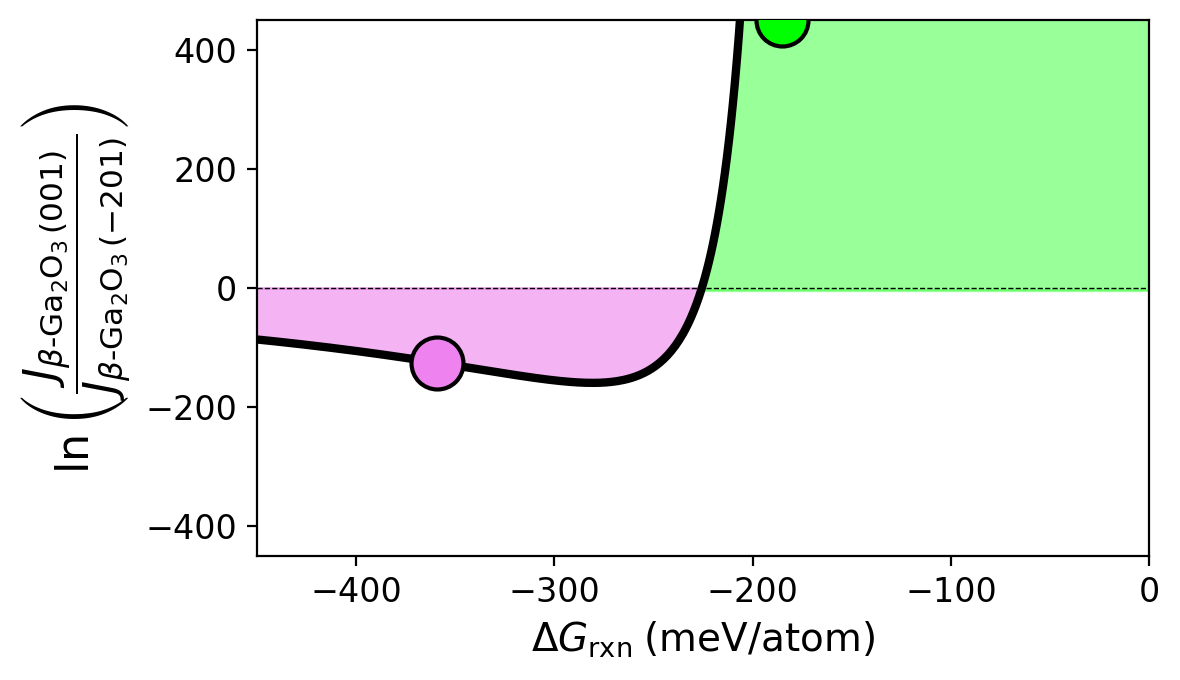

In [21]:
# Fontsize
fs = 16  # Font size

# Energy ranges (meV/atom)
delta_g_rxn = np.arange(-600, -150)
delta_g_rxn2 = np.arange(-650, -225)

# =============================================================================
# Plot: Nucleation Rate Ratio
# =============================================================================
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=200)

# Reaction point (TMGa)
ax.scatter(R_1_Grxn,ln_J_ratio_R_1,zorder=3,color="violet",s=350,edgecolors="black",linewidth=1.5)

# Reaction point (TEGa)
# Since the relative nucleation rate of TEGa diverges to infinity, it is displayed at the current upper limit of the plot, y=450, for visualization purposes.
ax.scatter(R_3_Grxn,450,zorder=3,color="lime",s=350,edgecolors="black",linewidth=1.5)

# Zero reference line
ax.axhline(0, color='black', linestyle='dashed', linewidth=0.5)

# Main nucleation rate curve
ln_J_ratio = np.log(nucleation_rate(
    surface_b201, density_b, 
    surface_b001, density_b, 
    delta_g_rxn, Ediff_201_001, temp
))
ax.plot(delta_g_rxn, ln_J_ratio, color='black', alpha=1, lw=3, label='ln(J ratio)',zorder=2)

# Shaded region for extended range
ln_J_ratio2 = np.log(nucleation_rate(
    surface_b201, density_b, 
    surface_b001, density_b, 
    delta_g_rxn2, Ediff_201_001, temp
))
ax.fill_between(delta_g_rxn2, ln_J_ratio2, color='violet', alpha=0.6, label=r'$\beta$-Ga$_2$O$_3$ (−201)')

mask = (delta_g_rxn >= -226) & (delta_g_rxn <= -200)
delta_g_selected = delta_g_rxn[mask]
ln_J_selected = ln_J_ratio[mask]

ax.fill_betweenx(ln_J_selected, delta_g_selected, 0, color='lime', alpha=0.4, label=r'$\beta$-Ga$_2$O$_3$ (001)')

# Axis settings
ax.set_xlim(-450, 0)
ax.set_ylim(-450, 450)
ax.tick_params(labelsize=fs - 4)

# Labels
ax.set_xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV/atom})$", fontsize=fs - 2)
ax.set_ylabel(
    r"$\ln \left(\dfrac{J_{\beta\text{-Ga}_{2}\text{O}_{3}\,(001)}}"
    r"{J_{\beta\text{-Ga}_{2}\text{O}_{3}\,(-201)}}\right)$",
    fontsize=fs
)

# Optional: add legend
# ax.legend(fontsize=fs - 6, loc='best')

plt.tight_layout()
plt.show()